In [ ]:
import pandas as pd

baseline = pd.read_csv("../../results/baseline/final_source_only_100_0.csv")
shape = pd.read_csv("../../results/new_wavelet/.csv")  # lambda = 0.05

# Rename columns to avoid clashes
baseline = baseline.add_prefix("base_")
shape = shape.add_prefix("shape_")

# Fix region names after prefixing
baseline = baseline.rename(columns={
    "base_source_region": "source_region",
    "base_target_region": "target_region"
})
shape = shape.rename(columns={
    "shape_source_region": "source_region",
    "shape_target_region": "target_region"
})

# Merge
merged = baseline.merge(shape, on=["source_region", "target_region"], how="inner")

merged["delta_iou"] = merged["shape_iou"] - merged["base_iou"]
# merged["delta_bf1"] = merged["shape_bf1"] - merged["base_bf1"]


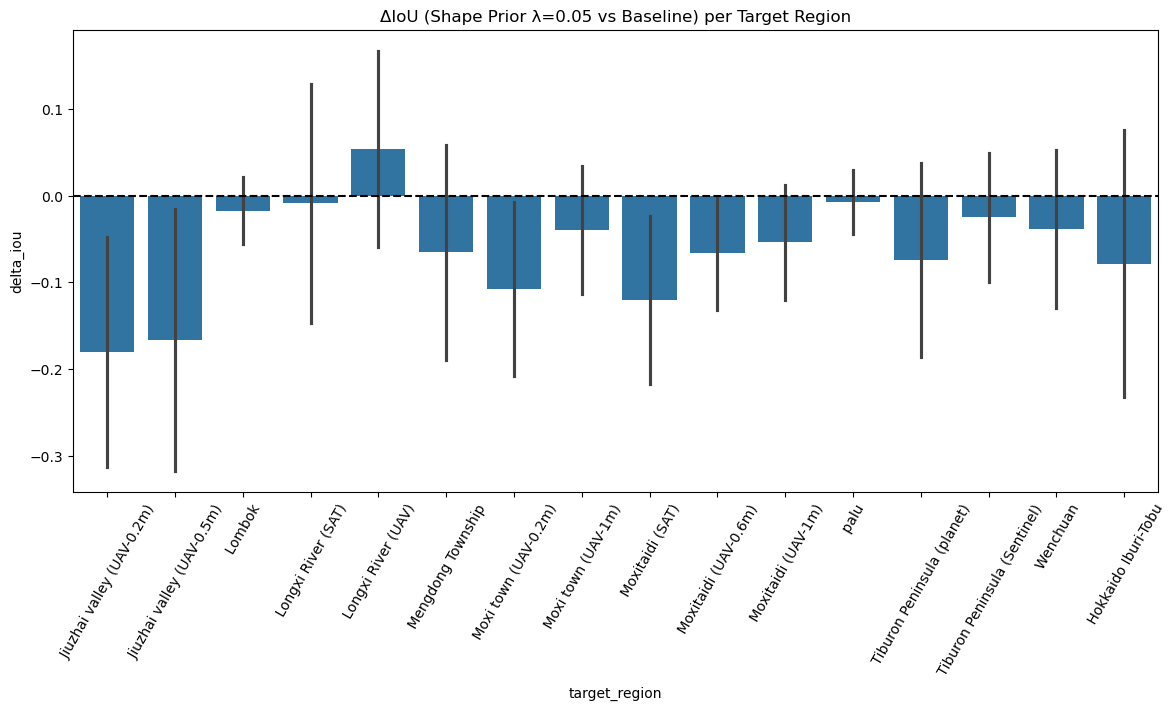

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
sns.barplot(
    data=merged,
    x="target_region",
    y="delta_iou",
    estimator="mean",
    errorbar="sd"
)
plt.axhline(0, color="black", linestyle="--")
plt.title("ΔIoU (Shape Prior λ=0.05 vs Baseline) per Target Region")
plt.xticks(rotation=60)
plt.show()


In [6]:
plt.figure(figsize=(14,6))
sns.barplot(
    data=merged,
    x="target_region",
    y="delta_bf1",
    estimator="mean",
    errorbar="sd"
)
plt.axhline(0, color="black", linestyle="--")
plt.title("ΔBF1 (Shape Prior λ=0.05 vs Baseline) per Target Region")
plt.xticks(rotation=60)
plt.show()


ValueError: Could not interpret value `delta_bf1` for `y`. An entry with this name does not appear in `data`.

<Figure size 1400x600 with 0 Axes>

In [ ]:
shape_stats = pd.read_csv("region_shape_stats.csv")

# Merge source stats
merged2 = merged.merge(
    shape_stats.add_prefix("src_"),
    left_on="source_region",
    right_on="src_region",
    how="left"
)

# Merge target stats
merged2 = merged2.merge(
    shape_stats.add_prefix("tgt_"),
    left_on="target_region",
    right_on="tgt_region",
    how="left"
)


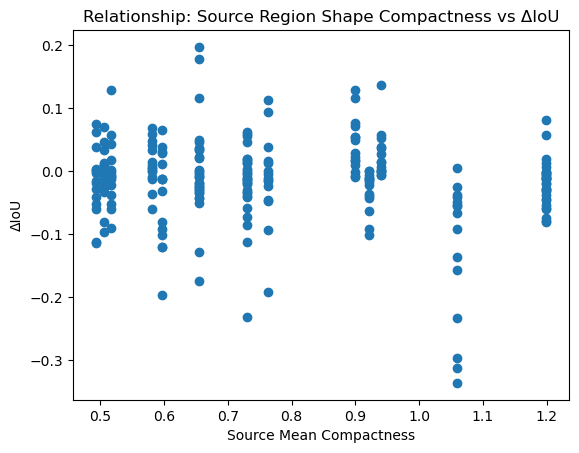

In [ ]:
plt.scatter(abs(merged2["src_mean_compactness"]), merged2["delta_iou"])
plt.xlabel("Source Mean Compactness")
plt.ylabel("ΔIoU")
plt.title("Relationship: Source Region Shape Compactness vs ΔIoU")
plt.show()

In [ ]:
features = [
    "src_mean_area", "src_mean_perimeter", "src_mean_compactness",
    "src_mean_axis_ratio", "src_mean_elongation", "src_mean_runout",
    "tgt_mean_area", "tgt_mean_perimeter", "tgt_mean_compactness",
    "tgt_mean_axis_ratio", "tgt_mean_elongation", "tgt_mean_runout",
]

corr = merged2[features + ["delta_iou"]].corr()["delta_iou"]
print(corr)


src_mean_area          -0.015158
src_mean_perimeter     -0.053977
src_mean_compactness   -0.135042
src_mean_axis_ratio    -0.027676
src_mean_elongation    -0.109317
src_mean_runout        -0.047272
tgt_mean_area                NaN
tgt_mean_perimeter           NaN
tgt_mean_compactness         NaN
tgt_mean_axis_ratio          NaN
tgt_mean_elongation          NaN
tgt_mean_runout              NaN
delta_iou               1.000000
Name: delta_iou, dtype: float64


In [ ]:
print("Heatmap target regions:")
print(sorted(merged["target_region"].unique()))

print("\nShape stats regions:")
print(sorted(shape_stats["region"].unique()))


Heatmap target regions:
[' Hokkaido Iburi-Tobu', ' Jiuzhai valley (UAV-0.2m)', ' Jiuzhai valley (UAV-0.5m)', ' Lombok', ' Longxi River (SAT)', ' Longxi River (UAV)', ' Mengdong Township', ' Moxi town (UAV-0.2m)', ' Moxi town (UAV-1m)', ' Moxitaidi (SAT)', ' Moxitaidi (UAV-0.6m)', ' Moxitaidi (UAV-1m)', ' Tiburon Peninsula (Sentinel)', ' Tiburon Peninsula (planet)', ' Wenchuan', ' palu']

Shape stats regions:
['Hokkaido Iburi-Tobu', 'Jiuzhai valley (UAV-0.2m)', 'Jiuzhai valley (UAV-0.5m)', 'Lombok', 'Longxi River (SAT)', 'Longxi River (UAV)', 'Mengdong Township', 'Moxi town (UAV-0.2m)', 'Moxi town (UAV-1m)', 'Moxitaidi (SAT)', 'Moxitaidi (UAV-0.6m)', 'Moxitaidi (UAV-1m)', 'Tiburon Peninsula (Sentinel)', 'Tiburon Peninsula (planet)', 'Wenchuan', 'palu']


In [ ]:
merged["source_region"] = merged["source_region"].str.strip()
merged["target_region"] = merged["target_region"].str.strip()
shape_stats["region"] = shape_stats["region"].str.strip()
merged2 = merged.merge(
    shape_stats.add_prefix("src_"),
    left_on="source_region",
    right_on="src_region",
    how="left"
)

merged2 = merged2.merge(
    shape_stats.add_prefix("tgt_"),
    left_on="target_region",
    right_on="tgt_region",
    how="left"
)
corr = merged2[features + ["delta_iou"]].corr()["delta_iou"]
print(corr)


src_mean_area          -0.015158
src_mean_perimeter     -0.053977
src_mean_compactness   -0.135042
src_mean_axis_ratio    -0.027676
src_mean_elongation    -0.109317
src_mean_runout        -0.047272
tgt_mean_area           0.044081
tgt_mean_perimeter      0.024815
tgt_mean_compactness    0.019516
tgt_mean_axis_ratio     0.010223
tgt_mean_elongation     0.003471
tgt_mean_runout         0.030552
delta_iou               1.000000
Name: delta_iou, dtype: float64


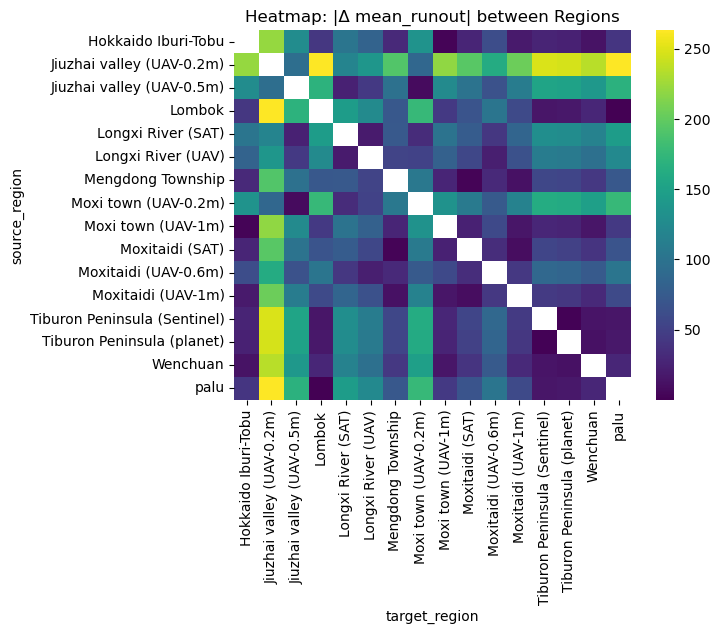

In [ ]:
feature = "mean_runout"

pivot = merged2.pivot(
    index="source_region",
    columns="target_region",
    values=f"src_{feature}"
) - merged2.pivot(
    index="source_region",
    columns="target_region",
    values=f"tgt_{feature}"
)

sns.heatmap(pivot.abs(), cmap="viridis")
plt.title(f"Heatmap: |Δ {feature}| between Regions")
plt.show()

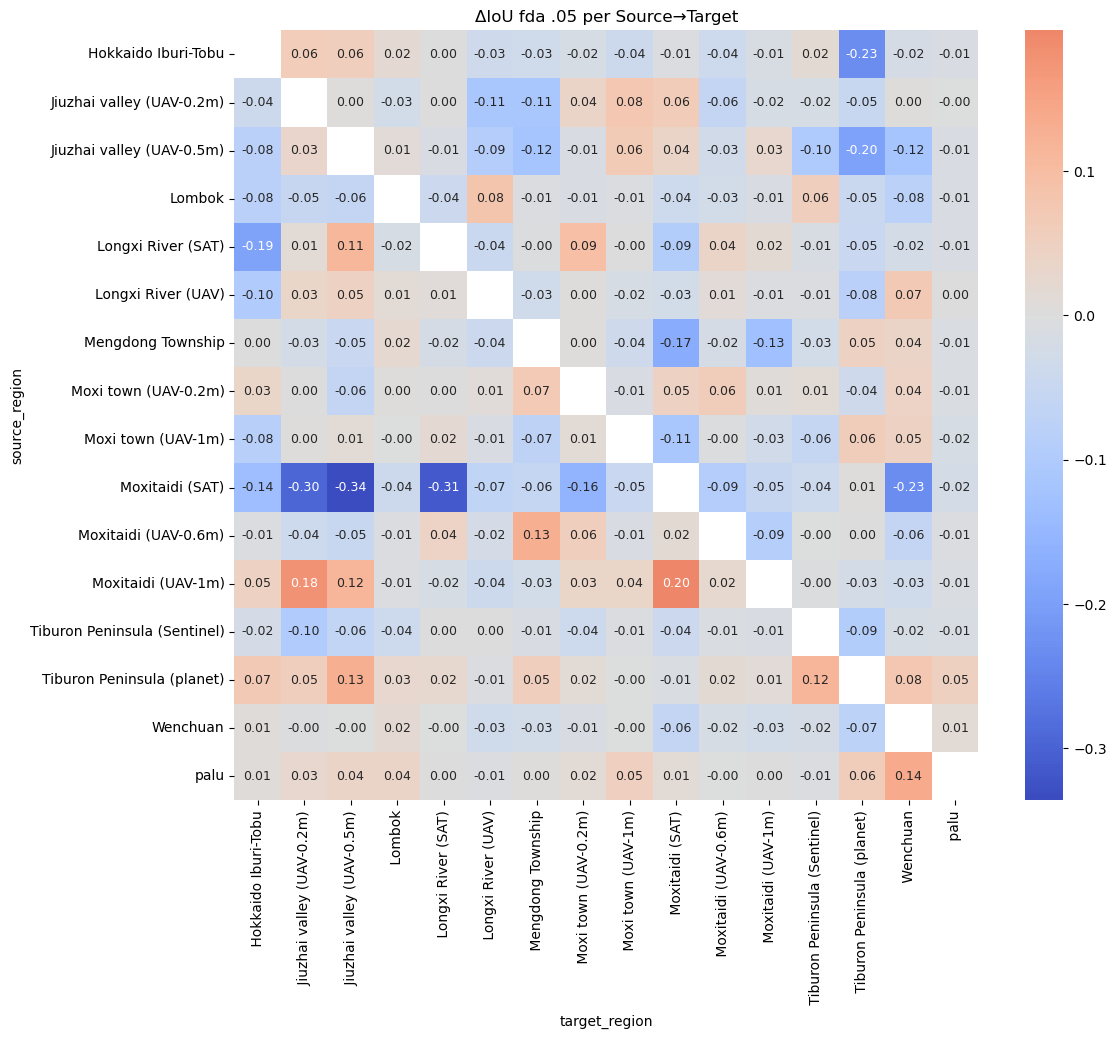

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot_iou = merged.pivot(
    index="source_region",
    columns="target_region",
    values="delta_iou"
)

plt.figure(figsize=(12,10))
sns.heatmap(
    pivot_iou,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".02f",
    annot_kws={"size": 9})
plt.title("ΔIoU fda .05 per Source→Target")
plt.show()


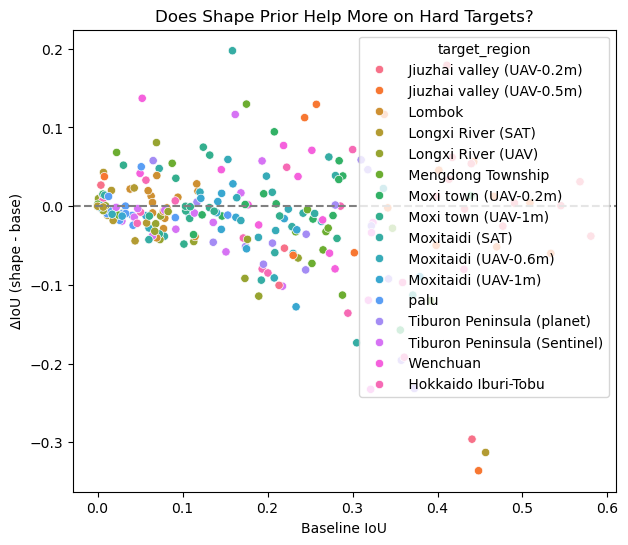

In [ ]:
plt.figure(figsize=(7,6))
sns.scatterplot(
    data=merged,
    x="base_iou",
    y="delta_iou",
    hue="target_region"
)
plt.axhline(0, linestyle="--", color="gray")
plt.xlabel("Baseline IoU")
plt.ylabel("ΔIoU (shape - base)")
plt.title("Does Shape Prior Help More on Hard Targets?")
plt.show()


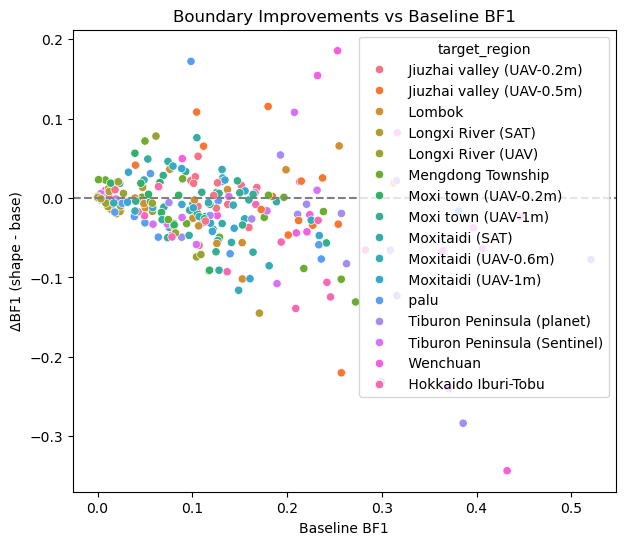

In [ ]:
plt.figure(figsize=(7,6))
sns.scatterplot(
    data=merged,
    x="base_bf1",
    y="delta_bf1",
    hue="target_region"
)
plt.axhline(0, linestyle="--", color="gray")
plt.xlabel("Baseline BF1")
plt.ylabel("ΔBF1 (shape - base)")
plt.title("Boundary Improvements vs Baseline BF1")
plt.show()


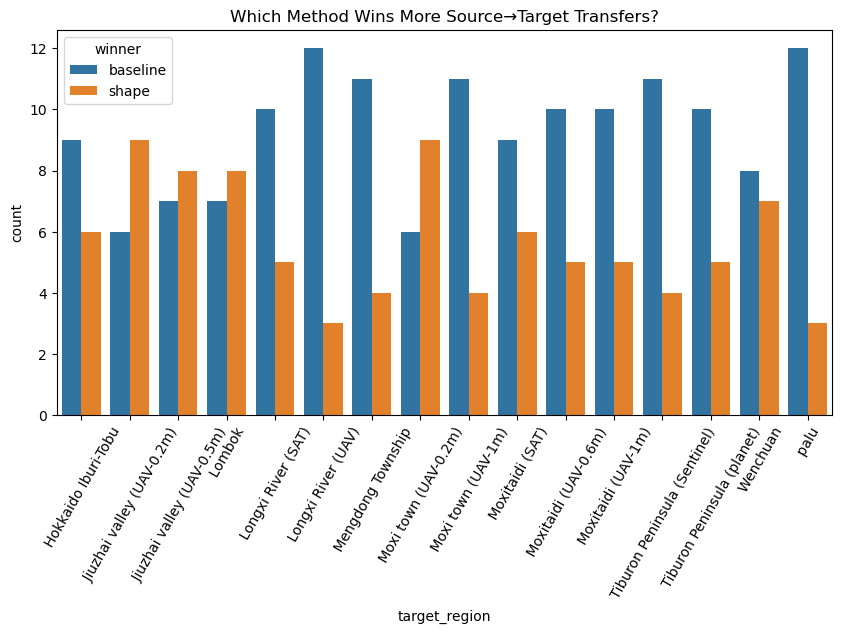

In [ ]:
merged["winner"] = merged["delta_iou"].apply(lambda x: "shape" if x>0 else "baseline")

win_counts = merged.groupby(["target_region","winner"]).size().reset_index(name="count")

plt.figure(figsize=(10,5))
sns.barplot(
    data=win_counts,
    x="target_region",
    y="count",
    hue="winner"
)
plt.title("Which Method Wins More Source→Target Transfers?")
plt.xticks(rotation=60)
plt.show()
